# Projet Machine Learning — Prédiction du churn client

## Objectif

L’objectif de ce projet est d’analyser les données clients d’une entreprise télécom afin d’identifier les facteurs liés au churn et de construire un modèle de Machine Learning capable de prédire les clients à risque.

## 1. Import des librairies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import joblib

## 2. Chargement des données

In [4]:
df = pd.read_csv("../data/customer_churn_raw.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Compréhension et qualité des données

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [14]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [15]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df["TotalCharges"].isnull().sum()

np.int64(11)

## 4. Nettoyage des données

In [18]:
df_clean = df.copy()

In [19]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

In [20]:
df_clean[df_clean["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [21]:
df_clean = df_clean.dropna(subset=["TotalCharges"])

In [22]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

In [23]:
df_clean.shape

(7032, 21)

In [24]:
df_clean.duplicated().sum()

np.int64(0)

In [25]:
df_clean = df_clean.drop(columns=["customerID"])

In [26]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [27]:
df_clean.to_csv("../data/customer_churn_clean.csv", index=False)

### Synthèse du nettoyage

La colonne `TotalCharges` était initialement reconnue comme une variable texte, alors qu’elle représente un montant numérique.

Après conversion en nombre, 11 valeurs manquantes ont été détectées. Ces lignes correspondent à des clients avec une ancienneté nulle ou très récente. Comme elles représentent une très faible part du dataset, elles ont été supprimées.

La colonne `customerID`, qui correspond à un identifiant client unique, a également été retirée car elle n’apporte pas d’information utile pour la modélisation.

Après nettoyage, le dataset contient 7 032 lignes exploitables.

## 5. Analyse exploratoire des données

L’objectif de cette étape est d’analyser la répartition du churn et d’identifier les variables qui semblent influencer le départ des clients.

In [28]:
churn_counts = df_clean["Churn"].value_counts()
churn_percent = df_clean["Churn"].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    "Nombre de clients": churn_counts,
    "Pourcentage": churn_percent.round(2)
})

churn_summary

,Nombre de clients,Pourcentage
Churn,,
No,5163,73.42
Yes,1869,26.58


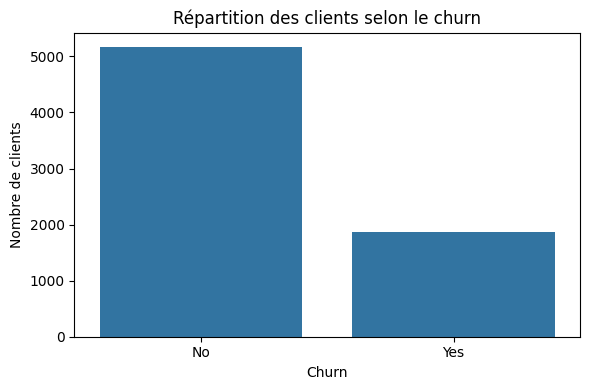

In [29]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="Churn"
)

plt.title("Répartition des clients selon le churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
contract_churn = (
    df_clean
    .groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

contract_churn["Proportion"] = contract_churn["Proportion"] * 100

contract_churn

,Contract,Churn,Proportion
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.722826
3,One year,Yes,11.277174
4,Two year,No,97.151335
5,Two year,Yes,2.848665


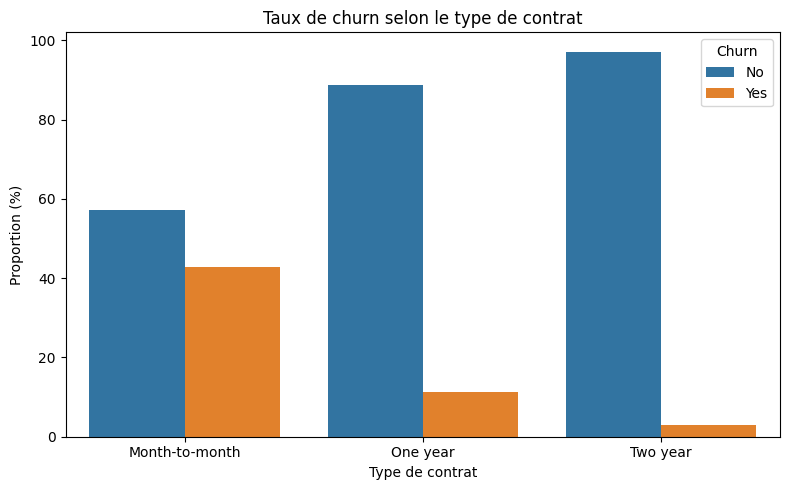

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Proportion",
    hue="Churn"
)

plt.title("Taux de churn selon le type de contrat")
plt.xlabel("Type de contrat")
plt.ylabel("Proportion (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_contract.png", dpi=300, bbox_inches="tight")
plt.show()

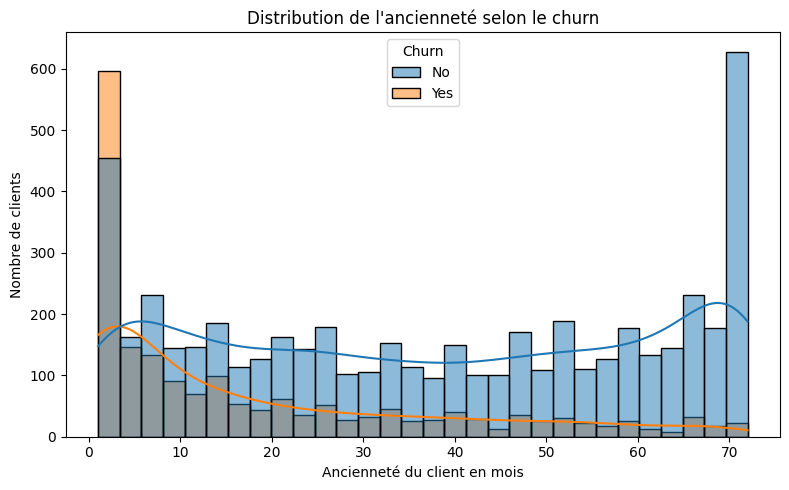

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Distribution de l'ancienneté selon le churn")
plt.xlabel("Ancienneté du client en mois")
plt.ylabel("Nombre de clients")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

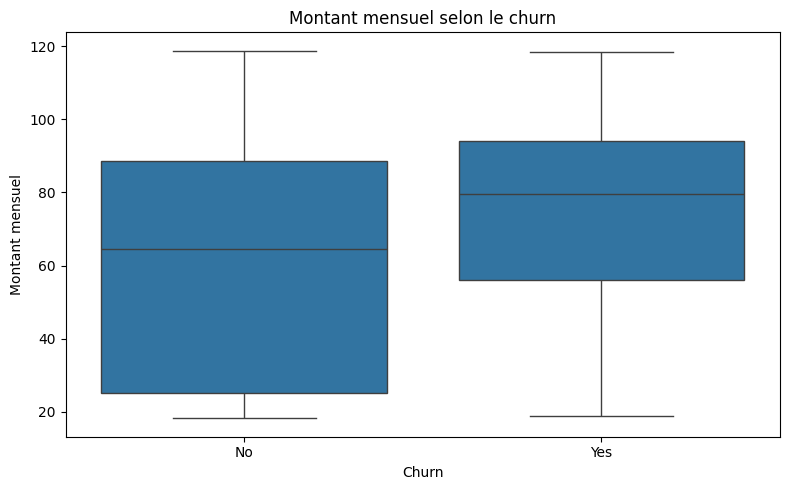

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Montant mensuel selon le churn")
plt.xlabel("Churn")
plt.ylabel("Montant mensuel")

plt.tight_layout()
plt.savefig("../outputs/figures/monthly_charges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

### Premiers constats exploratoires

L'analyse exploratoire montre que le churn concerne environ 26,5 % des clients, ce qui indique un déséquilibre modéré de la variable cible.

Le type de contrat semble fortement lié au churn : les clients avec un contrat mensuel (`Month-to-month`) présentent un taux de churn nettement plus élevé que les clients engagés sur un ou deux ans.

L'ancienneté est également un facteur important. Les clients qui quittent l'entreprise sont souvent des clients récents, ce qui montre que les premiers mois de la relation client sont particulièrement critiques.

Enfin, les clients qui churnent semblent avoir des montants mensuels plus élevés, ce qui suggère que le prix ou la perception de valeur du service peut influencer le départ des clients.

In [34]:
internet_churn = (
    df_clean
    .groupby("InternetService")["Churn"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

internet_churn["Proportion"] = internet_churn["Proportion"] * 100

internet_churn

,InternetService,Churn,Proportion
0,DSL,No,81.001656
1,DSL,Yes,18.998344
2,Fiber optic,No,58.107235
3,Fiber optic,Yes,41.892765
4,No,No,92.565789
5,No,Yes,7.434211


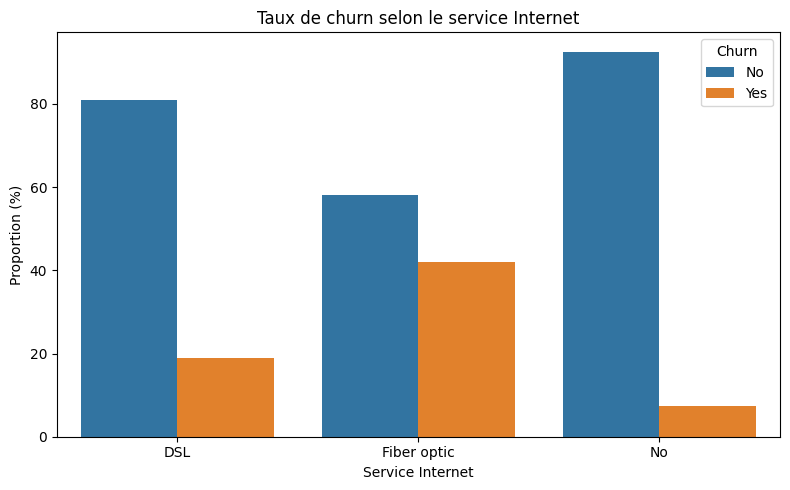

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Proportion",
    hue="Churn"
)

plt.title("Taux de churn selon le service Internet")
plt.xlabel("Service Internet")
plt.ylabel("Proportion (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_internet_service.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
payment_churn = (
    df_clean
    .groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

payment_churn["Proportion"] = payment_churn["Proportion"] * 100

payment_churn

,PaymentMethod,Churn,Proportion
0,Bank transfer (automatic),No,83.268482
1,Bank transfer (automatic),Yes,16.731518
2,Credit card (automatic),No,84.746877
3,Credit card (automatic),Yes,15.253123
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.798005
7,Mailed check,Yes,19.201995


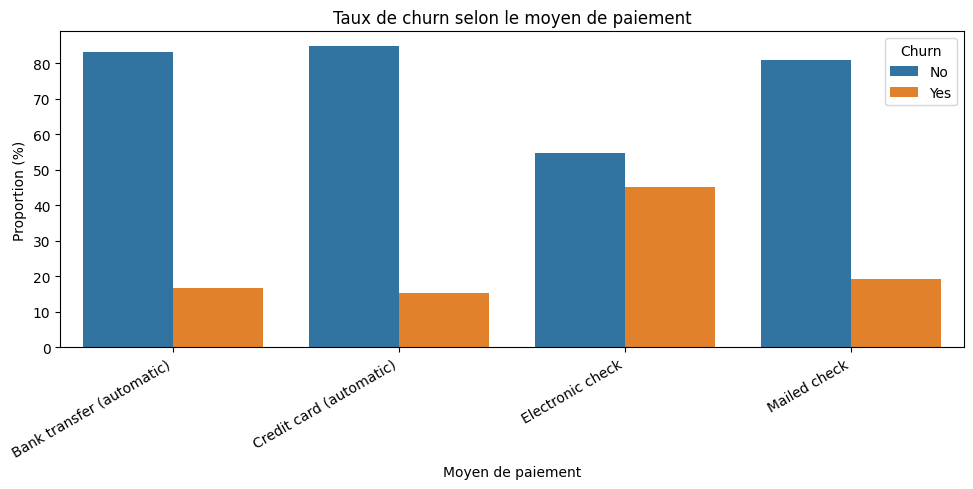

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="Proportion",
    hue="Churn"
)

plt.title("Taux de churn selon le moyen de paiement")
plt.xlabel("Moyen de paiement")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_payment_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
online_security_churn = (
    df_clean
    .groupby("OnlineSecurity")["Churn"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

online_security_churn["Proportion"] = online_security_churn["Proportion"] * 100

online_security_churn

,OnlineSecurity,Churn,Proportion
0,No,No,58.221333
1,No,Yes,41.778667
2,No internet service,No,92.565789
3,No internet service,Yes,7.434211
4,Yes,No,85.359801
5,Yes,Yes,14.640199


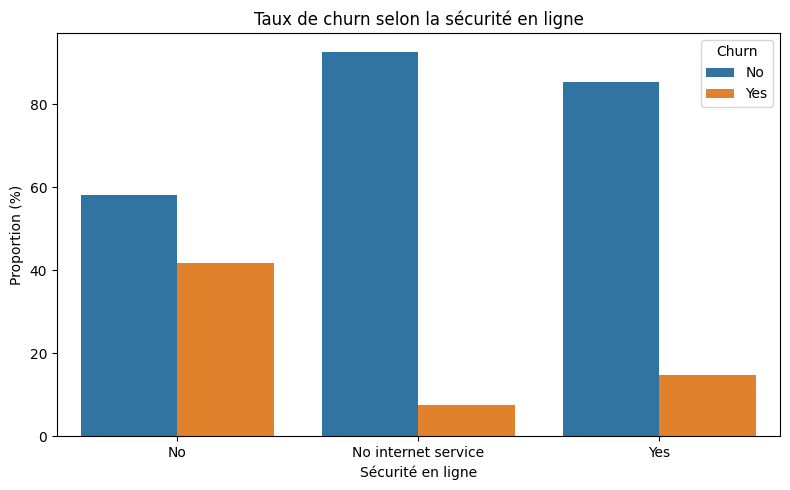

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=online_security_churn,
    x="OnlineSecurity",
    y="Proportion",
    hue="Churn"
)

plt.title("Taux de churn selon la sécurité en ligne")
plt.xlabel("Sécurité en ligne")
plt.ylabel("Proportion (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_online_security.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
tech_support_churn = (
    df_clean
    .groupby("TechSupport")["Churn"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

tech_support_churn["Proportion"] = tech_support_churn["Proportion"] * 100

tech_support_churn

,TechSupport,Churn,Proportion
0,No,No,58.352535
1,No,Yes,41.647465
2,No internet service,No,92.565789
3,No internet service,Yes,7.434211
4,Yes,No,84.803922
5,Yes,Yes,15.196078


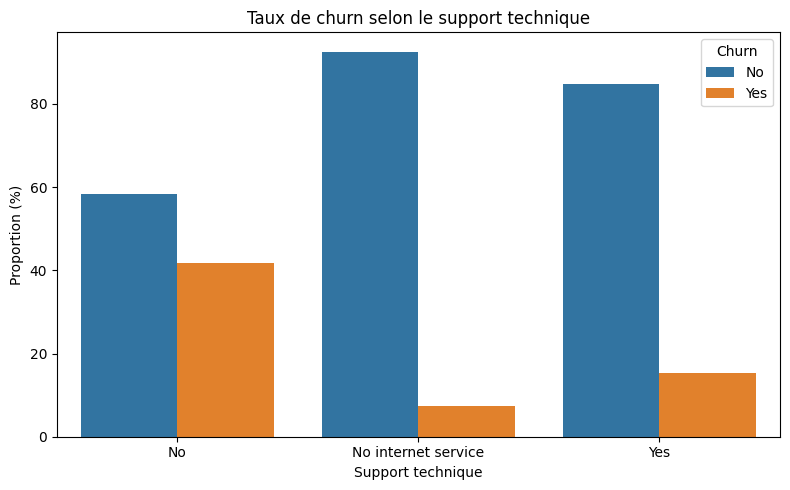

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tech_support_churn,
    x="TechSupport",
    y="Proportion",
    hue="Churn"
)

plt.title("Taux de churn selon le support technique")
plt.xlabel("Support technique")
plt.ylabel("Proportion (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/churn_by_tech_support.png", dpi=300, bbox_inches="tight")
plt.show()

### Synthèse de l’analyse exploratoire

L’analyse exploratoire met en évidence plusieurs facteurs associés au churn.

Les clients ayant un contrat mensuel (`Month-to-month`) quittent beaucoup plus souvent l’entreprise que ceux engagés sur un ou deux ans.  
L’ancienneté du client joue également un rôle important : les clients récents sont davantage exposés au churn.

Les clients qui churnent présentent aussi des montants mensuels plus élevés en moyenne.

Concernant les services, les clients utilisant l’offre `Fiber optic` semblent quitter davantage l’entreprise que ceux utilisant `DSL`.  
Le moyen de paiement influence également le churn : les clients payant par `Electronic check` présentent un taux de churn plus élevé que ceux utilisant des paiements automatiques.

Enfin, les services additionnels comme `OnlineSecurity` et `TechSupport` semblent réduire le risque de churn. Les clients qui ne bénéficient pas de ces services quittent plus souvent l’entreprise.

Ces observations suggèrent que le churn est influencé à la fois par le niveau d’engagement contractuel, l’ancienneté du client, le coût du service et la présence de services complémentaires.

In [42]:
df_model = df_clean.copy()

df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

df_model["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [43]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (7032, 19)
Dimensions de y : (7032,)


In [44]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Dimensions après encodage :", X_encoded.shape)
X_encoded.head()

Dimensions après encodage : (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (5625, 30)
X_test  : (1407, 30)
y_train : (5625,)
y_test  : (1407,)


In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisation terminée.")

Standardisation terminée.


In [47]:
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("X_train_scaled shape :", X_train_scaled.shape)
print("X_test_scaled shape  :", X_test_scaled.shape)

print("\nRépartition de y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nRépartition de y_test :")
print(y_test.value_counts(normalize=True) * 100)

X_train shape : (5625, 30)
X_test shape  : (1407, 30)
X_train_scaled shape : (5625, 30)
X_test_scaled shape  : (1407, 30)

Répartition de y_train :
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Répartition de y_test :
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


## 7. Construction des modèles de Machine Learning

L’objectif est d’entraîner plusieurs modèles de classification afin de prédire si un client risque de quitter l’entreprise.

Trois modèles sont testés :
- Régression logistique ;
- Arbre de décision ;
- Random Forest.

Les modèles seront comparés à l’aide de plusieurs métriques : accuracy, precision, recall et f1-score.

In [48]:
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(f"Résultats du modèle : {model_name}")
    print("-" * 40)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("\nRapport de classification :")
    print(classification_report(y_true, y_pred))

    return results

In [49]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred_log_reg = log_reg.predict(X_test_scaled)

log_reg_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log_reg
)

Résultats du modèle : Logistic Regression
----------------------------------------
Accuracy  : 0.8038
Precision : 0.6476
Recall    : 0.5749
F1-score  : 0.6091

Rapport de classification :
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [50]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree
)

Résultats du modèle : Decision Tree
----------------------------------------
Accuracy  : 0.7783
Precision : 0.5807
Recall    : 0.5963
F1-score  : 0.5884

Rapport de classification :
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [51]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Résultats du modèle : Random Forest
----------------------------------------
Accuracy  : 0.7505
Precision : 0.5205
Recall    : 0.7807
F1-score  : 0.6246

Rapport de classification :
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



## 8. Évaluation et comparaison des modèles

Les modèles sont comparés à l’aide des métriques principales de classification.
Dans un contexte de churn, le recall est particulièrement important, car l’objectif est d’identifier un maximum de clients réellement à risque.

In [52]:
model_results = pd.DataFrame([
    log_reg_results,
    tree_results,
    rf_results
])

model_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065
1,Decision Tree,0.778252,0.580729,0.596257,0.588391
2,Random Forest,0.750533,0.520499,0.780749,0.624599


In [53]:
model_results_sorted = model_results.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

model_results_sorted

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.750533,0.520499,0.780749,0.624599
1,Logistic Regression,0.803838,0.647590,0.574866,0.609065
2,Decision Tree,0.778252,0.580729,0.596257,0.588391


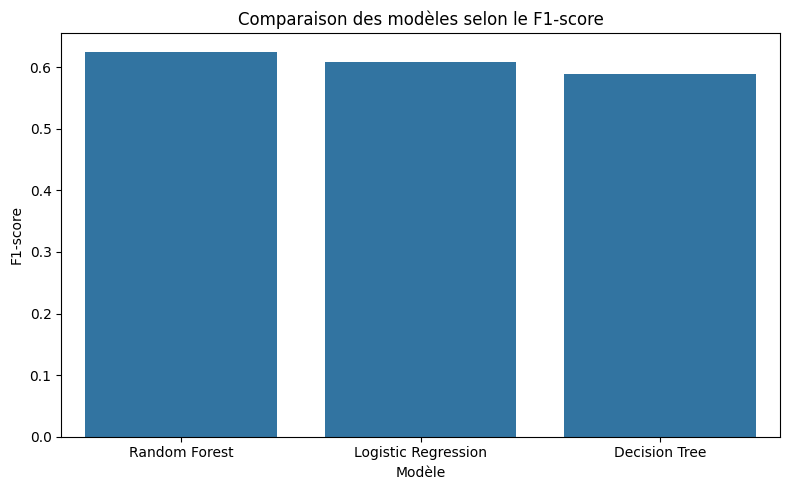

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results_sorted,
    x="Model",
    y="F1-score"
)

plt.title("Comparaison des modèles selon le F1-score")
plt.xlabel("Modèle")
plt.ylabel("F1-score")

plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison_f1_score.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
best_model_name = model_results_sorted.loc[0, "Model"]
best_model_name

'Random Forest'

In [56]:
best_predictions = {
    "Logistic Regression": y_pred_log_reg,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

y_pred_best = best_predictions[best_model_name]

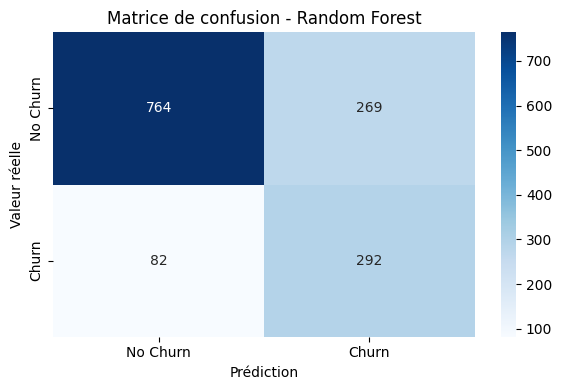

In [57]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(f"Matrice de confusion - {best_model_name}")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

### Interprétation des performances du meilleur modèle

Le modèle Random Forest obtient le meilleur F1-score parmi les modèles testés.

La matrice de confusion montre que le modèle identifie correctement une grande partie des clients qui churnent. Il détecte 292 clients churn sur 374 dans l’échantillon de test, soit un recall d’environ 78 % pour la classe churn.

Cependant, le modèle génère aussi des faux positifs : 269 clients sont prédits comme churn alors qu’ils ne quittent pas l’entreprise. Dans un contexte métier, cela peut être acceptable si l’objectif est de détecter un maximum de clients à risque afin de déclencher des actions de rétention.

Le modèle présente donc un bon compromis pour une première approche, mais pourrait être amélioré en ajustant le seuil de classification ou en optimisant les hyperparamètres.

## 9. Interprétation du modèle

L’objectif est d’identifier les variables les plus importantes dans la prédiction du churn afin de relier les résultats du modèle aux insights métier.

In [58]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,tenure,0.176724
1,TotalCharges,0.131926
2,Contract_Two year,0.126136
3,MonthlyCharges,0.083041
4,InternetService_Fiber optic,0.074423
5,PaymentMethod_Electronic check,0.060036
6,Contract_One year,0.049970
7,OnlineSecurity_Yes,0.039231
8,StreamingMovies_No internet service,0.023224
9,DeviceProtection_No internet service,0.022254


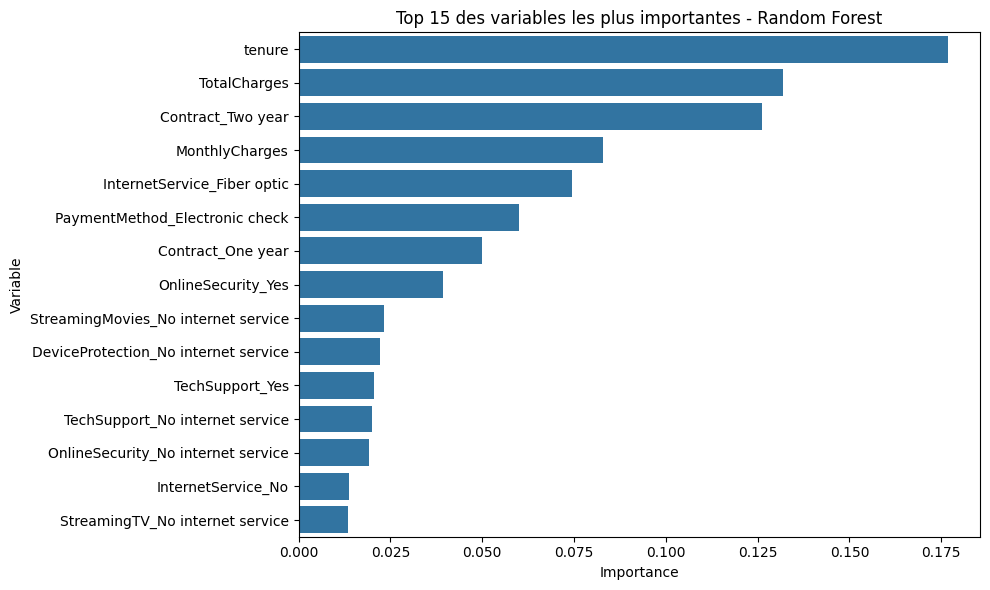

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 des variables les plus importantes - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.savefig("../outputs/figures/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Interprétation des variables importantes

Le modèle Random Forest identifie `tenure`, `TotalCharges`, `Contract_Two year`, `MonthlyCharges`, `InternetService_Fiber optic` et `PaymentMethod_Electronic check` comme les variables les plus importantes dans la prédiction du churn.

Ces résultats sont cohérents avec l’analyse exploratoire : les clients récents, les clients avec des contrats mensuels, les montants mensuels élevés et certains modes de paiement présentent un risque de churn plus élevé.

À l’inverse, les contrats longue durée ainsi que certains services additionnels comme `OnlineSecurity` et `TechSupport` semblent associés à une meilleure fidélisation.

## 10. Sauvegarde du modèle final

Le modèle Random Forest est retenu comme modèle final car il obtient le meilleur F1-score parmi les modèles testés.

In [60]:
final_model = random_forest

model_artifact = {
    "model": final_model,
    "features": X_train.columns.tolist()
}

joblib.dump(model_artifact, "../models/churn_random_forest_model.pkl")

['../models/churn_random_forest_model.pkl']

In [61]:
import os

os.listdir("../models")

['churn_random_forest_model.pkl']

## 11. Recommandations business

### Recommandations business

À partir de l’analyse exploratoire et des résultats du modèle, plusieurs recommandations peuvent être proposées afin de réduire le churn client.

1. **Renforcer l’accompagnement des nouveaux clients**

L’ancienneté (`tenure`) est la variable la plus importante dans le modèle. Les clients récents présentent un risque de churn plus élevé.  
Il serait donc pertinent de mettre en place un parcours d’onboarding renforcé pendant les premiers mois : suivi personnalisé, messages de bienvenue, assistance proactive et offres de fidélisation.

2. **Encourager les contrats longue durée**

Les clients avec des contrats `One year` ou `Two year` churnent beaucoup moins que ceux avec des contrats mensuels.  
L’entreprise pourrait proposer des avantages spécifiques pour inciter les clients à passer d’un contrat mensuel à un contrat annuel ou biannuel.

3. **Surveiller les clients avec des charges mensuelles élevées**

Les clients qui churnent ont tendance à avoir des `MonthlyCharges` plus élevés.  
Une analyse complémentaire pourrait être menée pour identifier les clients ayant un coût élevé mais une faible utilisation des services, afin de leur proposer des offres mieux adaptées.

4. **Analyser l’offre Fiber optic**

Les clients utilisant `Fiber optic` présentent un taux de churn plus élevé.  
Cela peut indiquer un problème de prix, de qualité perçue, de concurrence ou de satisfaction client. Une enquête ciblée sur cette population pourrait permettre d’identifier les causes précises.

5. **Réduire le risque lié au paiement par Electronic check**

Le moyen de paiement `Electronic check` est associé à un churn plus élevé.  
L’entreprise pourrait encourager les paiements automatiques par carte bancaire ou virement, qui semblent associés à une meilleure fidélisation.

6. **Promouvoir les services additionnels**

Les clients disposant de services comme `OnlineSecurity` et `TechSupport` churnent moins.  
Ces services peuvent être utilisés comme leviers de rétention, notamment pour les clients à risque.

7. **Mettre en place un score de risque de churn**

Le modèle peut être utilisé pour attribuer un score de risque à chaque client.  
Les équipes marketing ou relation client pourraient ensuite prioriser les actions de rétention sur les clients les plus à risque.

## 12. Conclusion

Ce projet a permis d’analyser les facteurs associés au churn client et de construire un modèle de Machine Learning capable d’identifier les clients à risque.

L’analyse exploratoire a montré que le churn est fortement lié à l’ancienneté du client, au type de contrat, au montant mensuel, au service Internet, au moyen de paiement et à la présence de services additionnels.

Après comparaison de plusieurs modèles, le Random Forest a été retenu comme modèle final grâce à son meilleur F1-score. Le modèle présente un bon recall sur la classe churn, ce qui est important dans un contexte de rétention client.

Ce projet montre que l’analyse de données et le Machine Learning peuvent aider une entreprise à mieux comprendre les causes du churn et à cibler plus efficacement ses actions de fidélisation.

## 13. Export des résultats

In [62]:
# Export du dataset nettoyé
df_clean.to_csv("../data/customer_churn_clean.csv", index=False)

# Export des résultats des modèles
model_results_sorted.to_csv("../outputs/results/model_comparison.csv", index=False)

# Export de l'importance des variables
feature_importance.to_csv("../outputs/results/feature_importance.csv", index=False)

print("Exports terminés.")

Exports terminés.


In [63]:
import os

print("Fichiers dans outputs/results :")
print(os.listdir("../outputs/results"))

print("\nFichiers dans models :")
print(os.listdir("../models"))

Fichiers dans outputs/results :
['feature_importance.csv', 'model_comparison.csv']

Fichiers dans models :
['churn_random_forest_model.pkl']


## 14. Synthèse finale du projet

Ce projet avait pour objectif d’analyser le churn client d’une entreprise télécom et de construire un modèle de Machine Learning capable d’identifier les clients à risque.

L’analyse exploratoire a montré que les facteurs les plus associés au churn sont l’ancienneté du client, le type de contrat, le montant mensuel, le service Internet, le moyen de paiement, la sécurité en ligne et le support technique.

Les clients les plus à risque sont principalement des clients récents, avec un contrat mensuel, des charges mensuelles élevées, un paiement par Electronic check, sans sécurité en ligne et sans support technique.

Plusieurs modèles ont été testés : régression logistique, arbre de décision et Random Forest. Le modèle Random Forest a obtenu le meilleur F1-score et a été retenu comme modèle final.

Ce projet montre comment l’analyse de données et le Machine Learning peuvent aider une entreprise à mieux cibler ses actions de fidélisation et à réduire le churn.